# PBC3.py test

In [1]:
%load_ext autoreload
%autoreload 2

from PBC3 import PBC3, PBC3Config
from PBC2_4 import PBC as PBC2
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import os
import time
import io
from pbc3_debug_patch import install_debug_patch

PBC3 = install_debug_patch(PBC3)

from PBC3_animation import animate_pbc3

In [2]:
def show_debug_candidates(PBC3, debug_text, original_image=None, data=None):
    lines = [line.strip() for line in debug_text.strip().splitlines() if line.strip()]
    parsed = [PBC3.parse_debug_line(line) for line in lines]
    parsed = [(line, d) for line, d in zip(lines, parsed) if d]

    candidates = [(line, d) for line, d in parsed if d.get("kind") == "CANDIDATE"]
    selected = [(line, d) for line, d in parsed if d.get("kind") == "SELECTED"]

    if not candidates:
        print("No CANDIDATE lines found.")
        return

    selected_d = selected[-1][1] if selected else None

    for i, (line, d) in enumerate(candidates, 1):
        is_selected = False
        if selected_d is not None:
            is_selected = all(
                int(d.get(k, -999999)) == int(selected_d.get(k, -888888))
                for k in ("channel", "x", "y", "w", "h", "cell_size")
            )

        print(
            f"Candidate {i}/{len(candidates)}"
            + ("  <-- SELECTED" if is_selected else "")
            + f" | score={d.get('score')} reduction={d.get('reduction')} bits={d.get('bits')}"
        )

        PBC3.show_debug_line(
            line,
            original_image=original_image,
            data=data,
        )

    if selected:
        print("Selected patch:")
        selected_line = selected[-1][0]
        try:
            PBC3.show_debug_line(
                selected_line,
                original_image=original_image,
                data=data,
            )
        except Exception:
            print(selected_line)
    else:
        print("No SELECTED line found in pasted text.")

# Compare with JPEG with matching quality rate (match by file size) and also AVIF by the same metric
# quality helpers match quality levels to rough bpp averages, to help give a starting scale for the matching
def comparison_demo(img, res, search_count=8, verbose=False):
    BPP_GUIDE = {
        "JPEG": [(1, 0.17), (5, 0.21), (10, 0.29), (20, 0.44), (40, 0.65), (60, 0.85), (80, 1.26), (95, 2.77)],
        "AVIF": [(0, 0.01), (2, 0.02), (5, 0.04), (10, 0.06), (20, 0.12), (40, 0.30), (60, 0.68), (80, 1.16), (95, 2.69)],
    }
    def guess_quality(fmt, target_bpp):
        """Inverse-interpolate the guideline table to pick a starting quality for `target_bpp`."""
        g = BPP_GUIDE[fmt]
        qs = [q for q, _ in g]
        bs = [b for _, b in g]
        if target_bpp <= bs[0]:
            return qs[0]
        if target_bpp >= bs[-1]:
            return qs[-1]
        for i in range(1, len(g)):
            if target_bpp <= bs[i]:
                f = (target_bpp - bs[i - 1]) / (bs[i] - bs[i - 1])
                return int(round(qs[i - 1] + f * (qs[i] - qs[i - 1])))
        return qs[-1]
    def efficiency_score(bpp, mse):
        return 1000 / (bpp * mse + 1e-9)
    def match_quality(target_bpp, fmt, search_count=8, verbose=False):
        min_q = 0 if fmt == "AVIF" else 1
        max_q = 95

        def encode_at(q):
            buf = io.BytesIO()
            img.save(buf, format=fmt, quality=int(q))
            data = buf.getvalue()
            bpp = len(data) / (img.width * img.height)
            return q, bpp, data

        lo, hi = min_q, max_q
        best = None

        for _ in range(search_count):
            q = (lo + hi) // 2
            q, bpp, data = encode_at(q)

            err = abs(bpp - target_bpp)
            if best is None or err < best[0]:
                best = (err, q, bpp, data)

            if verbose:
                print(f"{fmt} quality {q} -> bpp {bpp:.5f}, target {target_bpp:.5f}")

            if target_bpp > 0 and err / target_bpp < 0.03:
                break

            if bpp > target_bpp:
                hi = q - 1
            else:
                lo = q + 1

            if lo > hi:
                break

        for q in range(max(min_q, best[1] - 3), min(max_q, best[1] + 3) + 1):
            q, bpp, data = encode_at(q)
            err = abs(bpp - target_bpp)
            if verbose:
                print(f"{fmt} refine quality {q} -> bpp {bpp:.5f}")
            if err < best[0]:
                best = (err, q, bpp, data)

        return best[1], best[2]
    # calculate pbc bpp by dividing the compressed size by the number of pixels in the image
    pbc_bpp = len(res.data) / (img.width * img.height)
    print(f"PBC3 bpp: {pbc_bpp:.4f}")
    # match jpeg
    jpeg_quality, current_jpeg_bpp = match_quality(pbc_bpp, "JPEG", search_count=search_count, verbose=verbose)
    print(f"Matched JPEG quality: {jpeg_quality}, bpp: {current_jpeg_bpp:.4f}")
    avif_quality, current_avif_bpp = match_quality(pbc_bpp, "AVIF", search_count=search_count, verbose=verbose)
    print(f"Matched AVIF quality: {avif_quality}, bpp: {current_avif_bpp:.4f}")
    plt.figure(figsize=(24, 6))
    plt.subplot(1, 5, 1)
    plt.title(f"Original Image\n{img.width*img.height*3/1024:.2f} KB")
    plt.imshow(img)
    plt.axis("off")
    plt.subplot(1, 5, 2)
    res24 = PBC2.compress(img)
    plt.title(f"PBC2.4\nbpp: {len(res24.data) / (img.width * img.height):.4f}, size: {len(res24.data) / 1024:.2f} KB\nMSE: {res24.mse:.4f}\nEfficiency Score: {efficiency_score(len(res24.data) / (img.width * img.height), res24.mse):.1f}")
    plt.imshow(res24.image)
    plt.axis("off")
    plt.subplot(1, 5, 3)
    plt.title(f"PBC3\nbpp: {pbc_bpp:.4f}, size: {len(res.data) / 1024:.2f} KB\nMSE: {res.mse:.4f}\nEfficiency Score: {efficiency_score(pbc_bpp, res.mse):.1f}")
    plt.imshow(res.image)
    plt.axis("off")
    plt.subplot(1, 5, 4)
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=jpeg_quality)
    buf.seek(0)
    jpeg_img = Image.open(buf)
    plt.imshow(jpeg_img)
    plt.title(f"JPEG\nq: {jpeg_quality}, bpp: {current_jpeg_bpp:.4f}, size: {len(buf.getvalue()) / 1024:.2f} KB\nMSE: {np.mean((np.array(img).astype(int) - np.array(jpeg_img).astype(int)) ** 2):.4f}\nEfficiency Score: {efficiency_score(current_jpeg_bpp, np.mean((np.array(img).astype(int) - np.array(jpeg_img).astype(int)) ** 2)):.1f}")
    plt.axis("off")
    plt.subplot(1, 5, 5)
    buf = io.BytesIO()
    img.save(buf, format="AVIF", quality=avif_quality)
    buf.seek(0)
    avif_img = Image.open(buf)
    plt.imshow(avif_img)
    plt.title(f"AVIF\nq: {avif_quality}, bpp: {current_avif_bpp:.4f}, size: {len(buf.getvalue()) / 1024:.2f} KB\nMSE: {np.mean((np.array(img).astype(int) - np.array(avif_img).astype(int)) ** 2):.4f}\nEfficiency Score: {efficiency_score(current_avif_bpp, np.mean((np.array(img).astype(int) - np.array(avif_img).astype(int)) ** 2)):.1f}")
    plt.axis("off")
    plt.suptitle(f"Comparison of PBC3, PBC2.4, JPEG, and AVIF Compression for {img.width}x{img.height} Image", fontsize=16, y=1.06)
    plt.show()

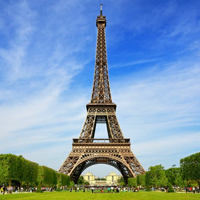

In [3]:
img = Image.open("test_images/eiffel.png")
img.resize((200, 200))

||||||||||||||||||||||||||||||||||||||||||||||||||
MSE: 105.72821044921875, Compressed Size: 20.49 KB
Verification successful: Encoded and decoded images are identical.


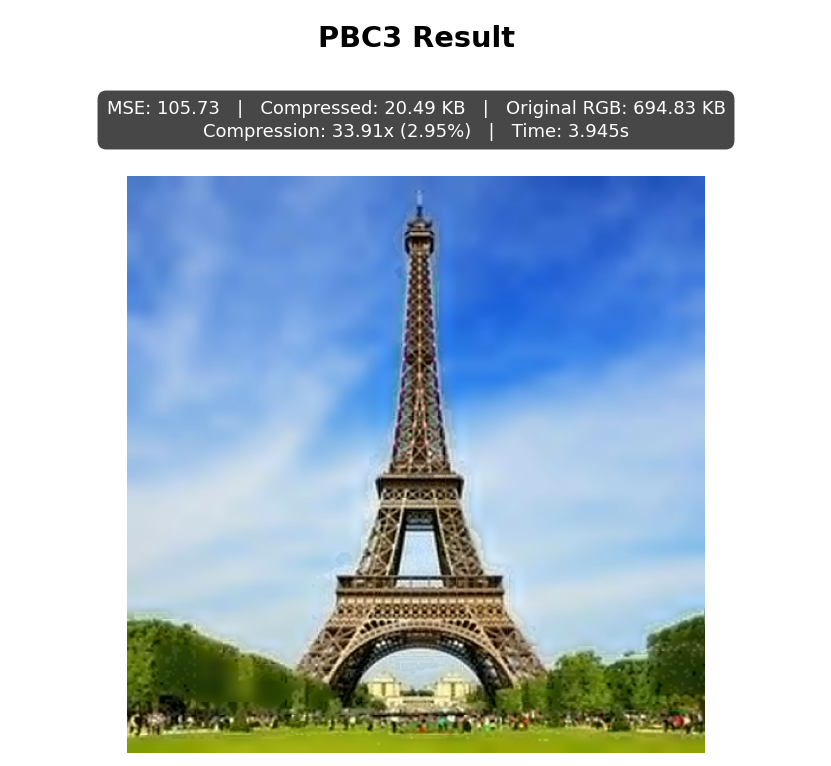

In [4]:
cfg = PBC3Config(
    patch_count=50,
    debug_print=True,
)

res = PBC3.compress(img, cfg)

print(f"MSE: {res.mse}, Compressed Size: {len(res.data) / 1024:.2f} KB")
if res.verify():
    print("Verification successful: Encoded and decoded images are identical.")
    res.show()
else:
    print("Verification failed: Encoded and decoded images differ.")
    decoded = PBC3.decompress(res.data)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title("Encoded Image")
    plt.imshow(res.image)
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.title("Decoded Image")
    plt.imshow(decoded.image)
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.title("Difference")
    diff = np.abs(np.array(res.image).astype(int) - np.array(decoded.image).astype(int))
    plt.imshow(diff)
    plt.axis("off")
    plt.show()

In [5]:
animate_pbc3(
    res.data,
    output_path=f"{img.filename}_pbc.mp4",
    fps=3,
    separated_channels=True,
    show_errors=True,
    original_image=img,
    fallback_to_gif=False,
)

'test_images/eiffel.png_pbc.mp4'

PBC3 bpp: 0.0885
Matched JPEG quality: 41, bpp: 0.0880
Matched AVIF quality: 57, bpp: 0.0902


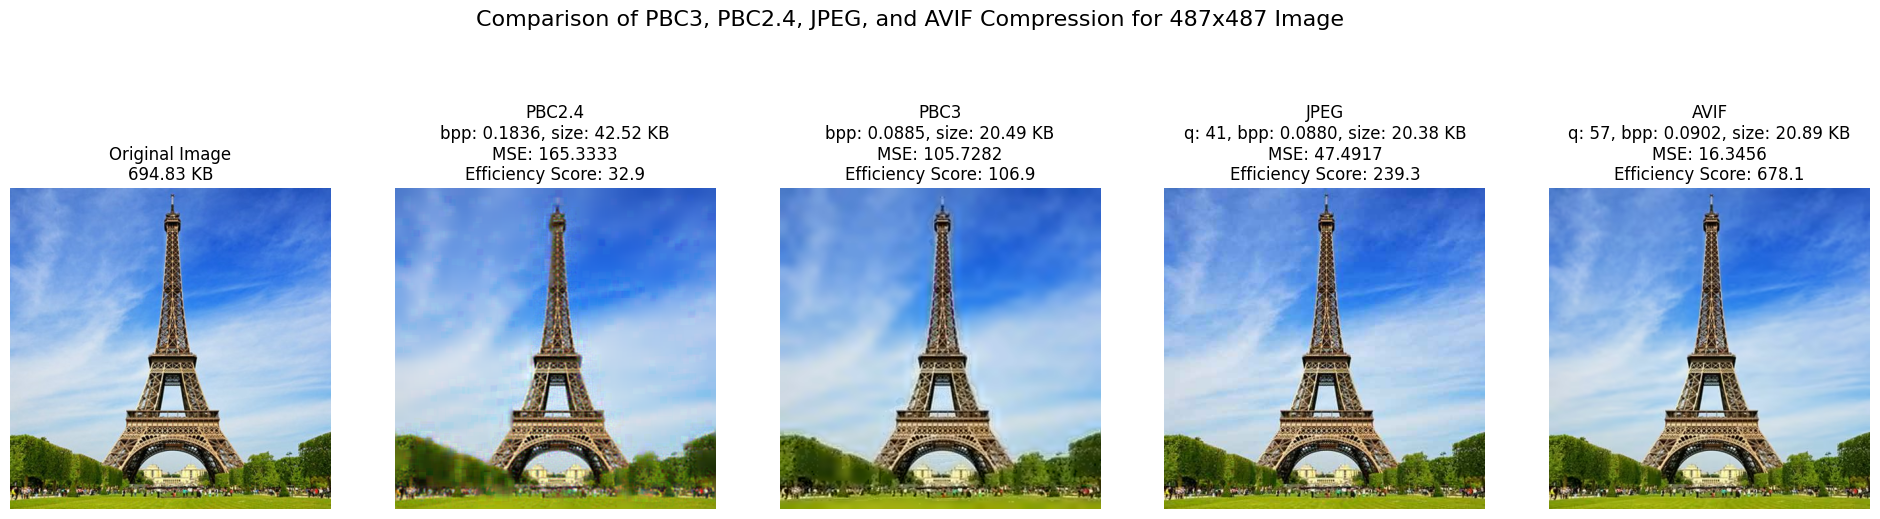

In [6]:
comparison_demo(img, res)

---

||||||||||||||||||||||||||||||||||||||||||||||||||
MSE: 157.47703552246094, Compressed Size: 14.40 KB
Verification successful: Encoded and decoded images are identical.


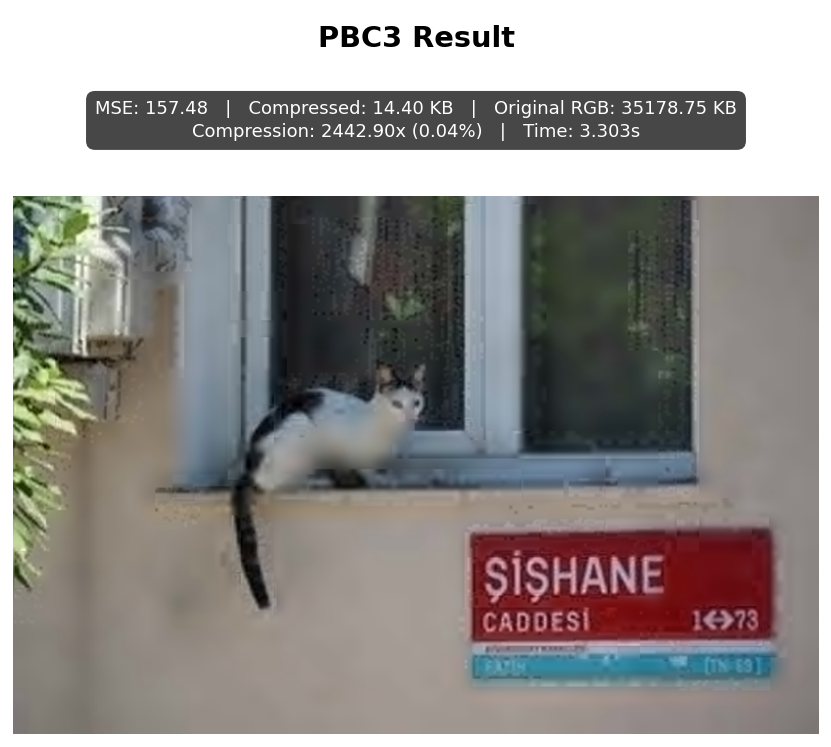

In [9]:
img = Image.open("test_images/sishane.JPG")

cfg = PBC3Config(
    debug_print=True,
)

res = PBC3.compress(img, cfg)

print(f"MSE: {res.mse}, Compressed Size: {len(res.data) / 1024:.2f} KB")
if res.verify():
    print("Verification successful: Encoded and decoded images are identical.")
    res.show()
else:
    print("Verification failed: Encoded and decoded images differ.")
    decoded = PBC3.decompress(res.data)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title("Encoded Image")
    plt.imshow(res.image)
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.title("Decoded Image")
    plt.imshow(decoded.image)
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.title("Difference")
    diff = np.abs(np.array(res.image).astype(int) - np.array(decoded.image).astype(int))
    plt.imshow(diff)
    plt.axis("off")
    plt.show()

In [6]:
animate_pbc3(
    res.data,
    output_path=f"{img.filename}_pbc.mp4",
    fps=3,
    separated_channels=True,
    show_errors=True,
    original_image=img,
    fallback_to_gif=False,
)

'test_images/sishane.JPG_pbc.mp4'

PBC3 bpp: 0.0012
Matched JPEG quality: 1, bpp: 0.0169
Matched AVIF quality: 3, bpp: 0.0013


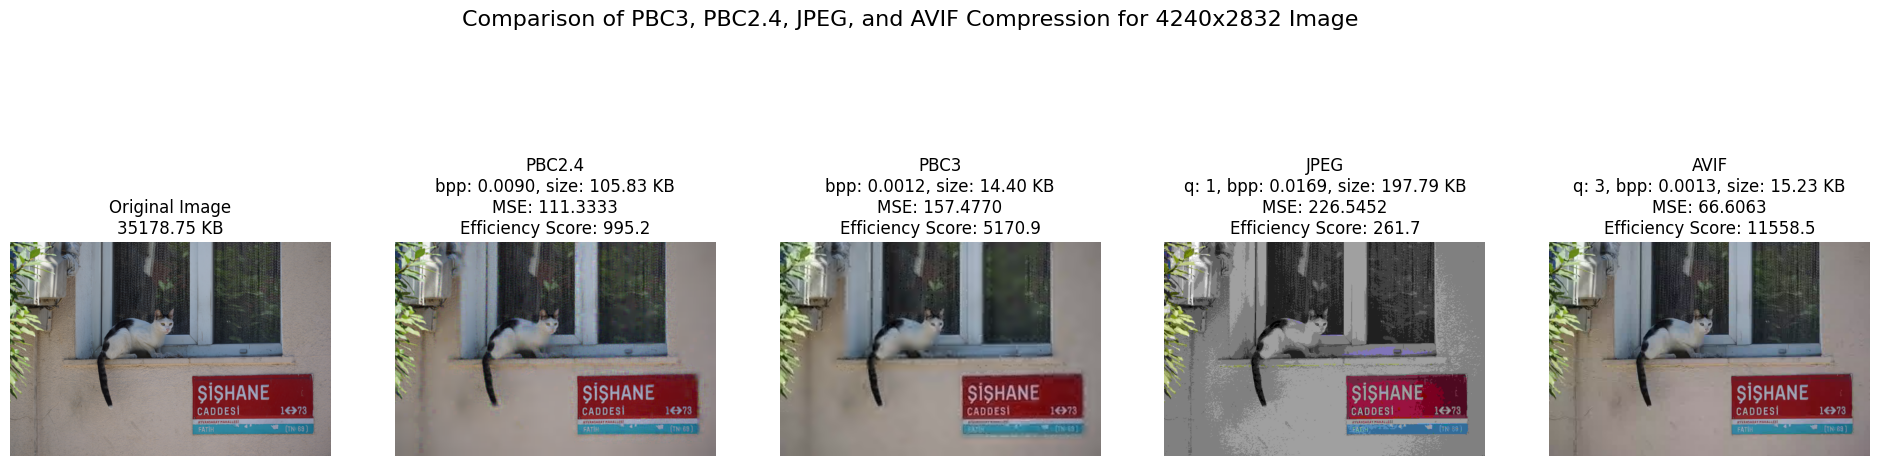

In [ ]:
comparison_demo(img, res, search_count=5)

||||||||||||||||||||||||||||||||||||||||||||||||||
MSE: 127.57772827148438, Compressed Size: 58.71 KB
Verification successful: Encoded and decoded images are identical.


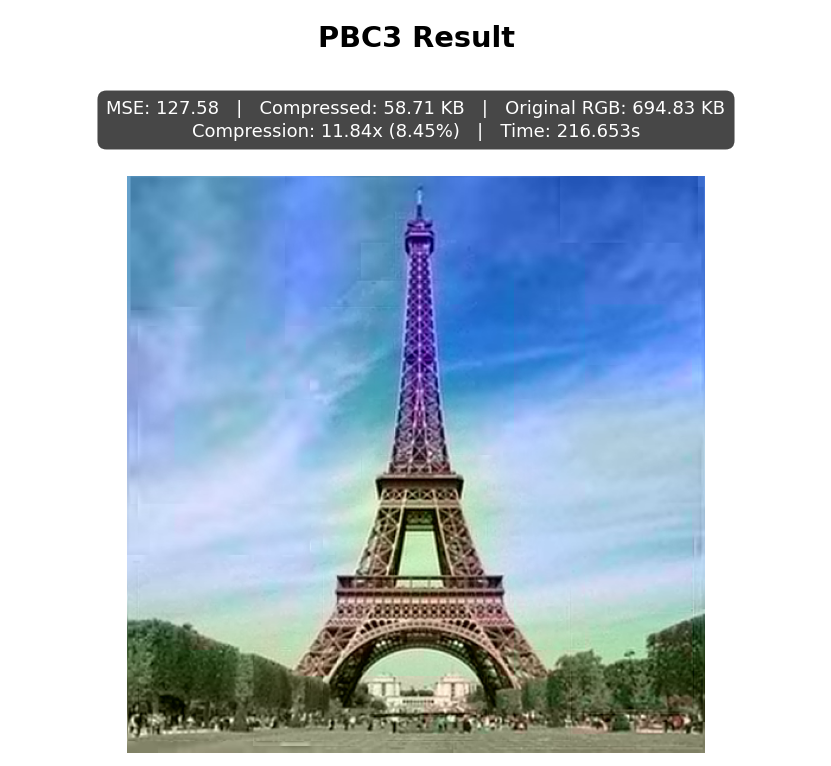

In [21]:
img = Image.open("test_images/eiffel.png")

cfg = PBC3Config(
    debug_print=True,
)

res = PBC3.compress(img, cfg)

print(f"MSE: {res.mse}, Compressed Size: {len(res.data) / 1024:.2f} KB")
if res.verify():
    print("Verification successful: Encoded and decoded images are identical.")
    res.show()
else:
    print("Verification failed: Encoded and decoded images differ.")
    decoded = PBC3.decompress(res.data)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title("Encoded Image")
    plt.imshow(res.image)
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.title("Decoded Image")
    plt.imshow(decoded.image)
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.title("Difference")
    diff = np.abs(np.array(res.image).astype(int) - np.array(decoded.image).astype(int))
    plt.imshow(diff)
    plt.axis("off")
    plt.show()

In [9]:
animate_pbc3(
    res.data,
    output_path=f"{img.filename}_pbc.mp4",
    fps=3,
    separated_channels=True,
    show_errors=True,
    original_image=img,
    fallback_to_gif=False,
)

'test_images/eiffel.png_pbc.mp4'

PBC3 bpp: 0.2535
Matched JPEG quality: 91, bpp: 0.2560
Matched AVIF quality: 92, bpp: 0.2509


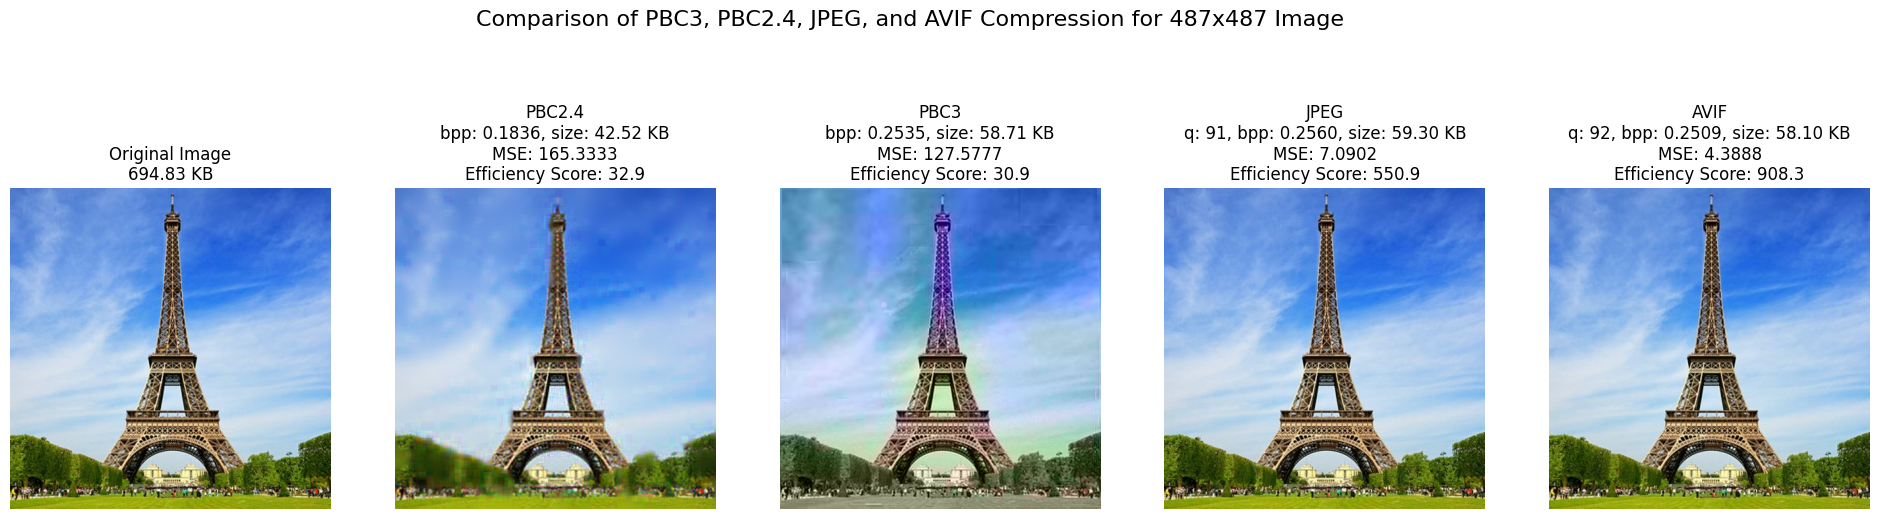

In [24]:
comparison_demo(img, res)

||||||||||||||||||||||||||||||||||||||||||||||||||
MSE: 243.53060913085938, Compressed Size: 13.96 KB
Verification successful: Encoded and decoded images are identical.


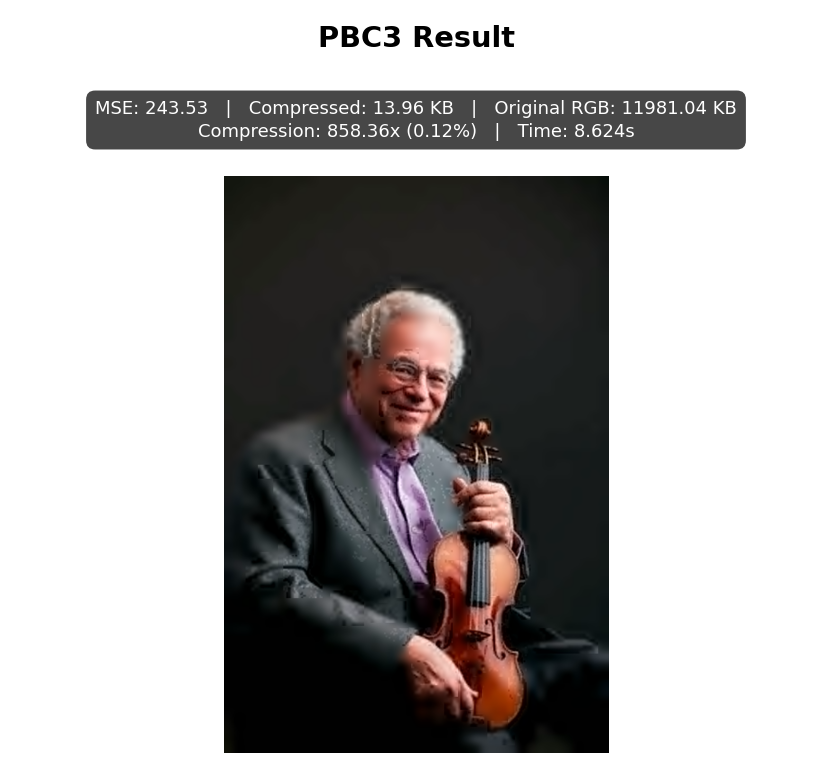

In [11]:
img = Image.open("test_images/test.png")
animate = False

cfg = PBC3Config(
    debug_print=True,
)

res = PBC3.compress(img, cfg)

print(f"MSE: {res.mse}, Compressed Size: {len(res.data) / 1024:.2f} KB")
if res.verify():
    print("Verification successful: Encoded and decoded images are identical.")
    res.show()
else:
    print("Verification failed: Encoded and decoded images differ.")
    decoded = PBC3.decompress(res.data)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title("Encoded Image")
    plt.imshow(res.image)
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.title("Decoded Image")
    plt.imshow(decoded.image)
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.title("Difference")
    diff = np.abs(np.array(res.image).astype(int) - np.array(decoded.image).astype(int))
    plt.imshow(diff)
    plt.axis("off")
    plt.show()

if animate:
    animate_pbc3(
        res.data,
        output_path=f"{img.filename}_pbc.mp4",
        fps=3,
        separated_channels=True,
        show_errors=True,
        original_image=img,
        scale=2,
        fallback_to_gif=False,
    )

PBC3 bpp: 0.0035
Matched JPEG quality: 1, bpp: 0.0194
Matched AVIF quality: 4, bpp: 0.0034


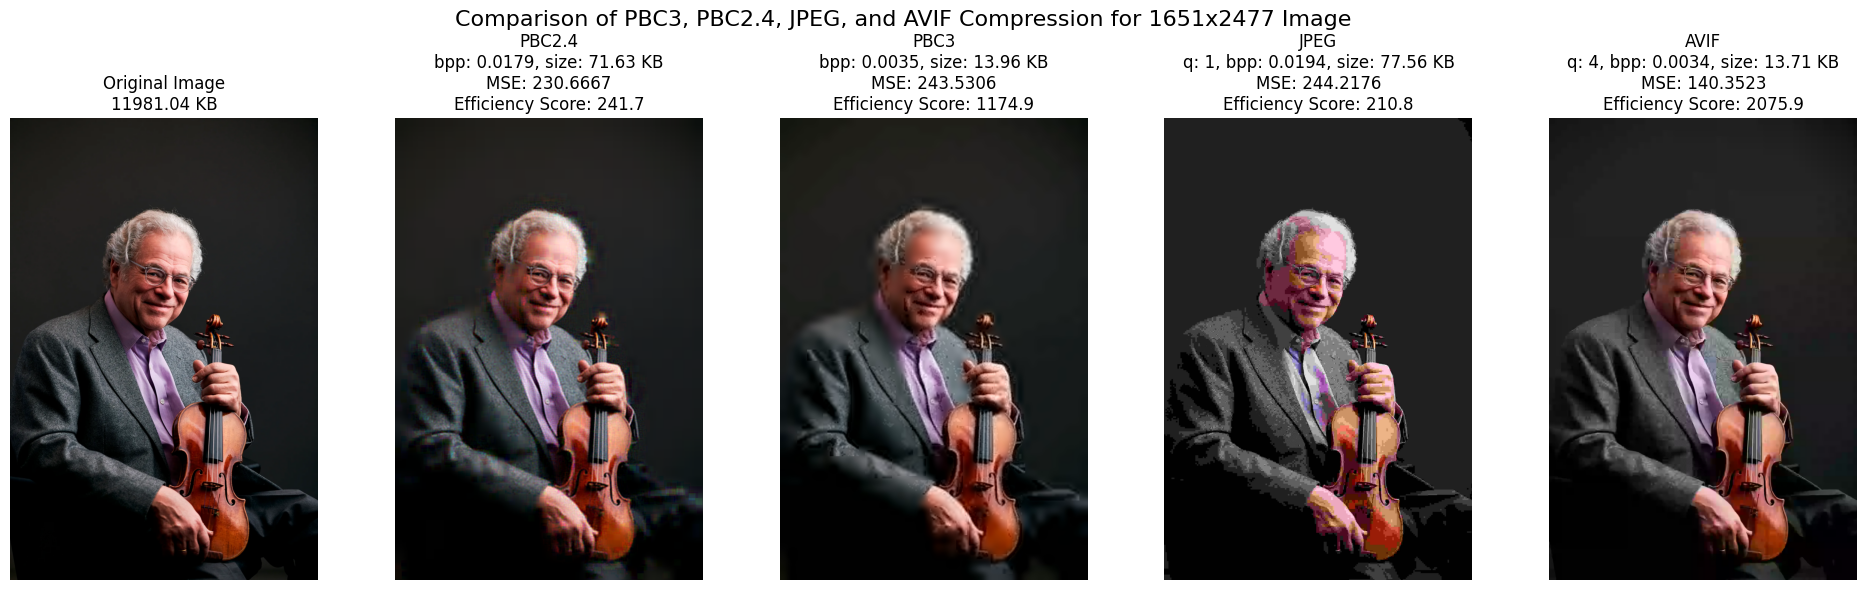

In [12]:
comparison_demo(img, res)